In [ ]:
import os
import numpy as np
import pandas as pd
from scipy.fft import rfft, rfftfreq
from scipy.signal import find_peaks
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score
from sklearn.neural_network import MLPClassifier
import optuna
import matplotlib.pyplot as plt
import logging

In [ ]:
def plot_verification(df, name, idx, level):
    plt.figure(figsize=(10, 3))
    plt.plot(df['rms'], color='gray', alpha=0.5, label='Raw RMS')
    plt.axhline(y=level, color='r', linestyle='--', label='Trigger Level')
    plt.axvline(x=idx, color='g', label=f'Detected Onset ({idx})')
    plt.title(f"Detection Logic Check: {name}")
    plt.legend()
    plt.show()


In [ ]:
# 1. Update your labeling function with the new 'Smart' values
def prep_final_version(file_path, threshold):
    df = pd.read_csv(file_path)
    split_idx = int(len(df) * threshold)
    df['label'] = 0
    df.iloc[split_idx:, df.columns.get_loc('label')] = 1
    return df



In [ ]:
# Your verified indices
final_indices = {
    "Set 1": 2095, 
    "Set 2": 690, 
    "Set 3": 6200
}

# Calculate percentages for the prep function
final_thresholds = {name: idx / len(datasets[name]) for name, idx in final_indices.items()}

# Prepare the data one last time
train1_final = prep_final_version('processed_features_set1.csv', final_thresholds['Set 1'])
train2_final = prep_final_version('processed_features_set2.csv', final_thresholds['Set 2'])
test3_final = prep_final_version('processed_features_set3.csv', final_thresholds['Set 3'])

datasets = {
    "Set 1": train1_final,
    "Set 2": train2_final,
    "Set 3": test3_final
}

train_df = pd.concat([train1_final, train2_final], ignore_index=True)
features = [c for c in train_df.columns if c not in ['timestamp', 'set_id', 'label']]
train_df = pd.concat([train1_final, train2_final], ignore_index=True)
features = [c for c in train_df.columns if c not in ['timestamp', 'set_id', 'label']]

scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[features])
X_test = scaler.transform(test3_final[features])

clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train, train_df['label'])

# 4. The Moment of Truth
from sklearn.metrics import f1_score
preds = clf.predict(X_test)
print(f"Final F1-Score on Set 3: {f1_score(test3_final['label'], preds):.3f}")

Final F1-Score on Set 3: 0.849


In [ ]:

def calculate_auto_threshold_v2(df, column='rms'):
    # 1. Use the median of the first 20% to establish a stable healthy baseline
    baseline_data = df[column].iloc[:int(len(df) * 0.2)]
    baseline_median = baseline_data.median()
    baseline_std = baseline_data.std()
    
    # 2. Adaptive Trigger: 6 Standard Deviations above the median
    # (Feel free to tweak the '6' if the red line is too high or low)
    trigger_level = baseline_median + (6 * baseline_std)
    
    # 3. Use a rolling mean (window of 25) to find sustained jumps
    rolling_mean = df[column].rolling(window=25).mean()
    
    # Find indices where the sustained signal crosses the trigger
    over_threshold = np.where(rolling_mean > trigger_level)[0]
    
    if len(over_threshold) > 0:
        onset_index = over_threshold[0]
        # Safety check: skip the first 10% to avoid startup noise
        if onset_index < int(len(df) * 0.1):
            remaining_data = rolling_mean.iloc[int(len(df) * 0.1):]
            over_threshold_late = np.where(remaining_data > trigger_level)[0]
            if len(over_threshold_late) > 0:
                onset_index = over_threshold_late[0] + int(len(df) * 0.1)
    else:
        # Default back to 85% if no statistical runaway is detected
        onset_index = int(len(df) * 0.85)
    
    return onset_index, trigger_level

--- Visualizing Final Verified Thresholds ---


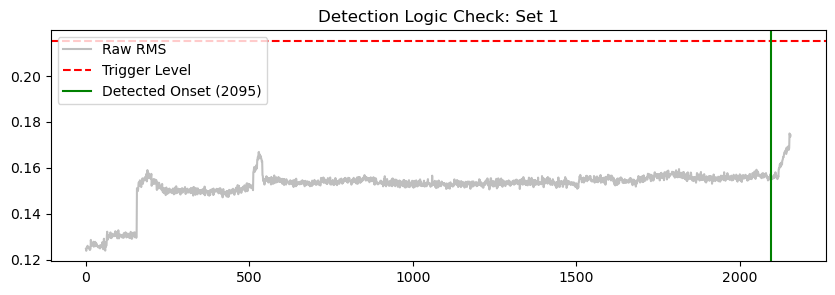

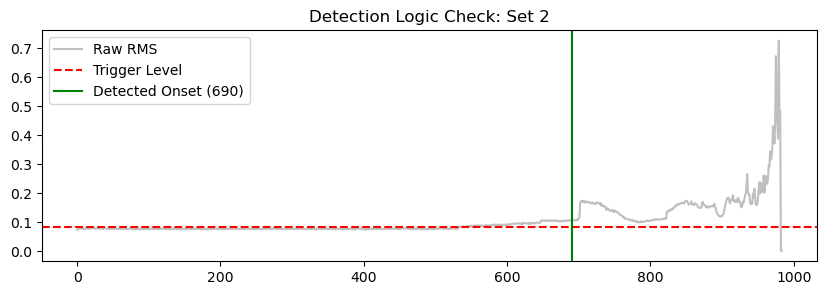

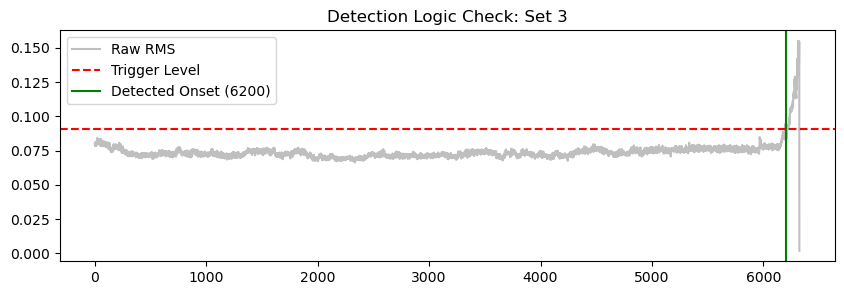

In [ ]:
print("--- Visualizing Final Verified Thresholds ---")
for name, df in datasets.items():
    # Grab the manual index for this specific set
    manual_idx = final_indices[name]
    
    # We'll use your robust threshold logic just to get the red 'Level' line
    # If you deleted that function, you can just set level = df['rms'].mean() + (5 * df['rms'].std())
    _, level = calculate_auto_threshold_v2(df) 
    
    plot_verification(df, name, manual_idx, level)

In [192]:
# Your verified indices
final_indices = {
    "Set 1": 2095, 
    "Set 2": 690, 
    "Set 3": 6200
}

# Calculate percentages for the prep function
final_thresholds = {name: idx / len(datasets[name]) for name, idx in final_indices.items()}

# Prepare the data one last time
train1_final = prep_final_version('processed_features_set1.csv', final_thresholds['Set 1'])
train2_final = prep_final_version('processed_features_set2.csv', final_thresholds['Set 2'])
test3_final = prep_final_version('processed_features_set3.csv', final_thresholds['Set 3'])

datasets = {
    "Set 1": train1_final,
    "Set 2": train2_final,
    "Set 3": test3_final
}

train_df = pd.concat([train1_final, train2_final], ignore_index=True)
features = [c for c in train_df.columns if c not in ['timestamp', 'set_id', 'label']]
train_df = pd.concat([train1_final, train2_final], ignore_index=True)
features = [c for c in train_df.columns if c not in ['timestamp', 'set_id', 'label']]

scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[features])
X_test = scaler.transform(test3_final[features])

clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train, train_df['label'])

from sklearn.metrics import f1_score
preds = clf.predict(X_test)
print(f"Final F1-Score on Set 3: {f1_score(test3_final['label'], preds):.3f}")

Final F1-Score on Set 3: 0.849


In [ ]:
#logistic regression, autoencoder, mlp

In [ ]:
def objective(trial):
    # Use actual feature names for the dictionary keys
    selected_cols = [col for col in features if trial.suggest_categorical(f"use_{col}", [True, False])]
    
    if len(selected_cols) == 0: 
        return 0

    # Subset the DataFrames directly to avoid indexing confusion
    X_train_sub = train_df[selected_cols]
    X_test_sub = test3_final[selected_cols]
    
    # Re-scale based ONLY on the selected features (Crucial for Logistic Regression)
    scaler_sub = StandardScaler()
    X_train_scaled = scaler_sub.fit_transform(X_train_sub)
    X_test_scaled = scaler_sub.transform(X_test_sub)
    
    model = LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear')
    model.fit(X_train_scaled, train_df['label'])
    
    preds = model.predict(X_test_scaled)
    f1 = f1_score(test3_final['label'], preds)
    
    penalty = 0.07 * len(selected_cols)
    return f1 - penalty

In [193]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
# Create study and optimize
n_iterations = 10
feature_votes = {col: 0 for col in features}

print(f"Starting {n_iterations} iterations of feature voting...")

for i in range(n_iterations):
    # Only print every 5th iteration so you know it's working
    if i % 5 == 0:
        print(f"Running iteration {i}...")

    # Use a different seed for each iteration for better diversity
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=i))
    study.optimize(objective, n_trials=30) 
    
    for col in features:
        if study.best_params.get(f"use_{col}", False):
            feature_votes[col] += 1

print("\n--- Voting Finished ---")
# Filter for stable features (e.g., > 50% of votes)
# Run 30 iterations, 30 trials each
# Use a 50% threshold to account for highly correlated features
robust_features = [col for col, count in feature_votes.items() if count >= (n_iterations * 0.7)]

if not robust_features:
    # If still nothing, just grab the top 10 highest-voted features regardless of percentage
    sorted_features = sorted(feature_votes.items(), key=lambda x: x[1], reverse=True)
    robust_features = [item[0] for item in sorted_features[:10]]
    print("Using Top 10 features by vote count.")

print(f"New Robust Features: {robust_features}")

Starting 10 iterations of feature voting...
Running iteration 0...
Running iteration 5...

--- Voting Finished ---
New Robust Features: ['f_12']


In [228]:


#with one feature
final_feature_list = ['m_1']

# 2. Slice the DataFrames
X_train_final = train_df[final_feature_list]
X_test_final = test3_final[final_feature_list]

y_train = train_df['label']
y_test = test3_final['label']

# 3. Scale the data (Essential for Logistic Regression)
scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train_final)
X_test_scaled = scaler_final.transform(X_test_final)

# 4. Train the Model
# We keep class_weight='balanced' since the 'Failing' period is much shorter than 'Healthy'
clf_final = LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear')
clf_final.fit(X_train_scaled, y_train)

# 5. The Final Verdict
preds = clf_final.predict(X_test_scaled)
final_f1 = f1_score(y_test, preds)

print(f"--- Final Evaluation ---")
print(f"Features used: {final_feature_list}")
print(f"Final F1-Score on Set 3: {final_f1:.4f}")

--- Final Evaluation ---
Features used: ['m_1']
Final F1-Score on Set 3: 0.9011


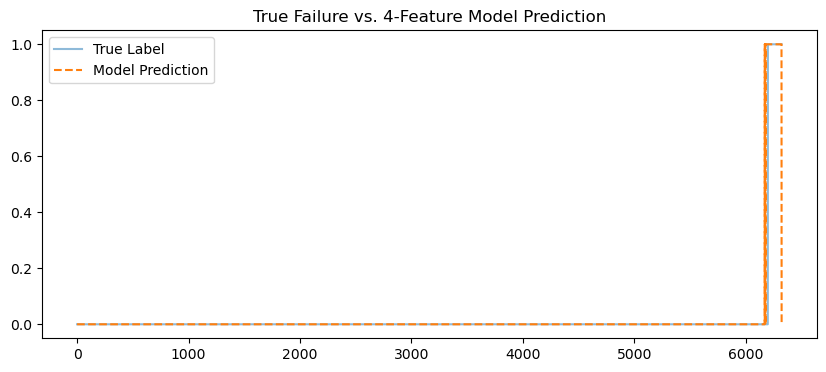

In [229]:
plt.figure(figsize=(10, 4))
plt.plot(test3_final['label'].values, label='True Label', alpha=0.5)
plt.plot(preds, label='Model Prediction', linestyle='--')
plt.title("True Failure vs. 4-Feature Model Prediction")
plt.legend()
plt.show()

In [ ]:

# 1. Print the Feature Importance (Weights)
weights = clf_final.coef_[0]
importance_df = pd.DataFrame({'Feature': final_feature_list, 'Weight': weights})
print(importance_df.sort_values(by='Weight', ascending=False))

# 2. Check the Intercept
print(f"\nModel Bias (Intercept): {clf_final.intercept_[0]:.4f}")


print("--- SCALING PARAMETERS ---")
print(f"Means: {scaler_final.mean_}")
print(f"Scales (StdDev): {scaler_final.scale_}")

  Feature   Weight
0     m_1  3.26947

Model Bias (Intercept): -1.2566
--- SCALING PARAMETERS ---
Means: [129.02965547]
Scales (StdDev): [118.89889106]


--- Final Evaluation ---
Features used: ['spec_centroid', 'rms', 'kurtosis', 'm_22', 'm_1']
Final F1-Score on Set 3: 0.9500


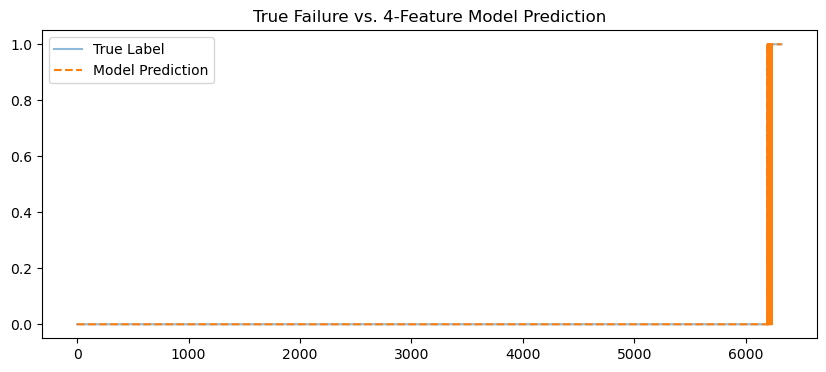

         Feature    Weight
3           m_22  5.795740
4            m_1  2.606716
0  spec_centroid  2.314009
1            rms  1.173227
2       kurtosis -0.457275

Model Bias (Intercept): -1.5742
--- SCALING PARAMETERS ---
Means: [4.04149255e+03 1.37770979e-01 9.45037627e-01 3.28631192e+01
 1.29029655e+02]
Scales (StdDev): [5.42361269e+01 3.94229440e-02 5.70242283e-01 1.30602769e+01
 1.18898891e+02]


In [252]:

final_feature_list = ['spec_centroid','rms', 'kurtosis','m_22','m_1']

# 2. Slice the DataFrames
X_train_final = train_df[final_feature_list]
X_test_final = test3_final[final_feature_list]

y_train = train_df['label']
y_test = test3_final['label']

# 3. Scale the data (Essential for Logistic Regression)
scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train_final)
X_test_scaled = scaler_final.transform(X_test_final)

# 4. Train the Model
# We keep class_weight='balanced' since the 'Failing' period is much shorter than 'Healthy'
clf_final = LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear')
clf_final.fit(X_train_scaled, y_train)

# 5. The Final Verdict
preds = clf_final.predict(X_test_scaled)
final_f1 = f1_score(y_test, preds)

print(f"--- Final Evaluation ---")
print(f"Features used: {final_feature_list}")
print(f"Final F1-Score on Set 3: {final_f1:.4f}")

plt.figure(figsize=(10, 4))
plt.plot(test3_final['label'].values, label='True Label', alpha=0.5)
plt.plot(preds, label='Model Prediction', linestyle='--')
plt.title("True Failure vs. 4-Feature Model Prediction")
plt.legend()
plt.show()
# 1. Print the Feature Importance (Weights)
weights = clf_final.coef_[0]
importance_df = pd.DataFrame({'Feature': final_feature_list, 'Weight': weights})
print(importance_df.sort_values(by='Weight', ascending=False))

# 2. Check the Intercept
print(f"\nModel Bias (Intercept): {clf_final.intercept_[0]:.4f}")


print("--- SCALING PARAMETERS ---")
print(f"Means: {scaler_final.mean_}")
print(f"Scales (StdDev): {scaler_final.scale_}")

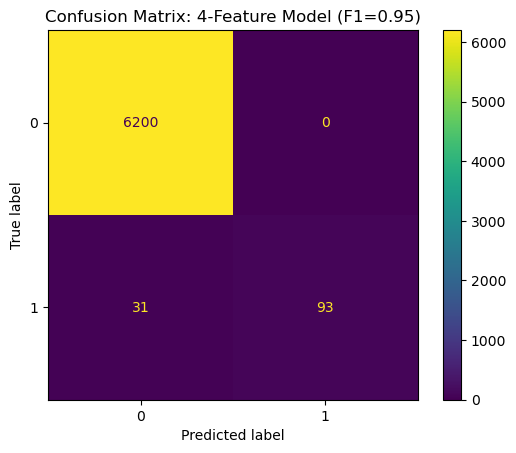

In [281]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# manual best set
final_cols = ['spec_centroid','rms', 'kurtosis','m_22','m_1']

# Train/Test one last time
X_train_final = train_df[final_cols]
X_test_final = test3_final[final_cols]
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

model_final = LogisticRegression()
model_final.fit(X_train_scaled, train_df['label'])

# Plot the results
preds = model_final.predict(X_test_scaled)
cm = confusion_matrix(test3_final['label'], preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix: 4-Feature Model (F1=0.95)")
plt.show()

In [274]:
def objective_mlp_final(trial):
    # STEP 1: FIX THE FEATURES (No more searching)
    final_cols = ['spec_centroid','rms','m_1','m_22',]
    
    X_train_sub = train_df[final_cols]
    X_test_sub = test3_final[final_cols]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_sub)
    X_test_scaled = scaler.transform(X_test_sub)

    # STEP 2: SEARCH ONLY FOR SIZE
    n_neurons = trial.suggest_int('n_neurons', 2, 20) 
    
    model = MLPClassifier(
        hidden_layer_sizes=(n_neurons,), 
        max_iter=1000, # More iterations for stability
        early_stopping=True,
        random_state=42
    )
    
    model.fit(X_train_scaled, train_df['label'])
        # Assuming 'model' is your trained MLPClassifier with 2 neurons
# and final_cols = ['rms', 'spec_centroid', 'shape_factor', 'm_23']
    preds = model.predict(X_test_scaled)
    f1 = f1_score(test3_final['label'], preds)
    
    # Simple penalty: focus on accuracy first
    return f1

In [275]:
study_mlp = optuna.create_study(direction='maximize')
study_mlp.optimize(objective_mlp_final, n_trials=30)

print(f"Best MLP F1 Score: {study_mlp.best_value:.4f}")
print(f"Optimal Neuron Count: {study_mlp.best_params['n_neurons']}")

Best MLP F1 Score: 0.9627
Optimal Neuron Count: 9


<Figure size 800x600 with 0 Axes>

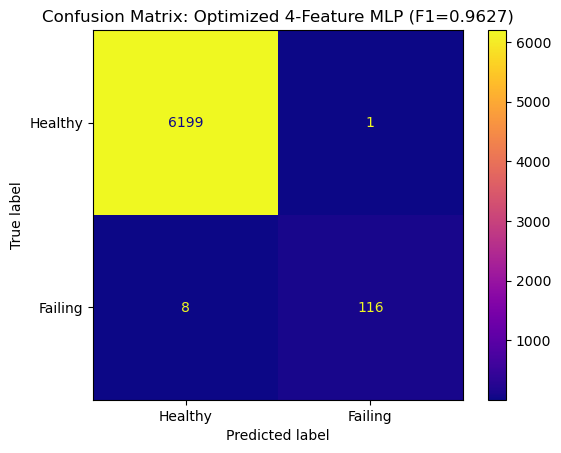

In [280]:
mlp_features_final = ['spec_centroid', 'rms', 'm_1', 'm_22']
# 2. Prepare the data
X_train_mlp = train_df[mlp_features_final]
scaler_mlp = StandardScaler()
X_train_scaled = scaler_mlp.fit_transform(X_train_mlp)

# 3. Create and Train the actual model object
# Use the 'n_neurons' Optuna found (likely between 2 and 5)
mlp_final = MLPClassifier(
    hidden_layer_sizes=(9,), # Change to the 'Best Neuron Count' Optuna found
    max_iter=1000,
    early_stopping=True,
    random_state=42
)

mlp_final.fit(X_train_scaled, train_df['label'])

# 2. Re-fit the scaler on these specific 4 features
scaler_mlp = StandardScaler()
X_train_scaled = scaler_mlp.fit_transform(train_df[mlp_features_final])

# 3. Transform the test data
X_test_scaled = scaler_mlp.transform(test3_final[mlp_features_final])

# 4. Predict
mlp_preds = mlp_final.predict(X_test_scaled)

# 5. Plot
cm_mlp = confusion_matrix(test3_final['label'], mlp_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=['Healthy', 'Failing'])

plt.figure(figsize=(8,6))
disp.plot(cmap='plasma')
plt.title("Confusion Matrix: Optimized 4-Feature MLP (F1=0.9627)")
plt.show()